# Poverty, Income & Asthma Correlation Analysis

**Purpose:** Load ACS socioeconomic indicator data and asthma incidence data, visualize poverty and income trends by borough, and compare socioeconomic predictors against asthma incidence.

**Data sources:**
- `data_csv/ACS_socioeconomic_indicators_2010-2024_Data.csv`
- `data_csv/merged_asthma_data.csv`

**Primary outputs:**
- Borough-level plots of ACS poverty and income trends
- Correlation summaries between asthma incidence and socioeconomic predictors

**Dependencies:**
- Python 3.8+
- `pandas`, `numpy`, `matplotlib`

**How to run:**
1. Activate the project virtual environment if present:
```bash
source .venv/bin/activate
```
2. Confirm the required CSV files exist in `data_csv/`.
3. Run notebook cells sequentially to regenerate the visualizations and correlation results.

**Notes & reproducibility:**
- This notebook assumes borough names and year columns are present in the ACS and asthma CSVs. Column name detection is performed dynamically, but review the input headers if the notebook fails to locate expected fields.
- Data joins are performed on normalized borough names and year values to compare poverty, income, and asthma incidence consistently.

**Author / Maintainer:** Mayank Anand — mayank.anand3007@gmail.com

In [1]:
# Consolidated imports
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("grayscale")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "0.85",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

BOROUGH_MARKER_STYLES = {
    "manhattan": {"marker": "o", "markersize": 5.5, "linestyle": "-", "facecolor": "white"},
    "bronx": {"marker": "s", "markersize": 6.0, "linestyle": "--", "facecolor": "black"},
    "brooklyn": {"marker": "^", "markersize": 6.5, "linestyle": ":", "facecolor": "white"},
    "queens": {"marker": "D", "markersize": 6.0, "linestyle": "-.", "facecolor": "white"},
    "staten island": {"marker": "P", "markersize": 6.5, "linestyle": (0, (5, 2)), "facecolor": "black"},
}

SERIES_MARKER_STYLES = {
    "income": {"marker": "o", "size": 70, "edgecolor": "black", "facecolor": "white", "line_style": "-"},
    "poverty": {"marker": "^", "size": 80, "edgecolor": "black", "facecolor": "0.2", "line_style": "--"},
}


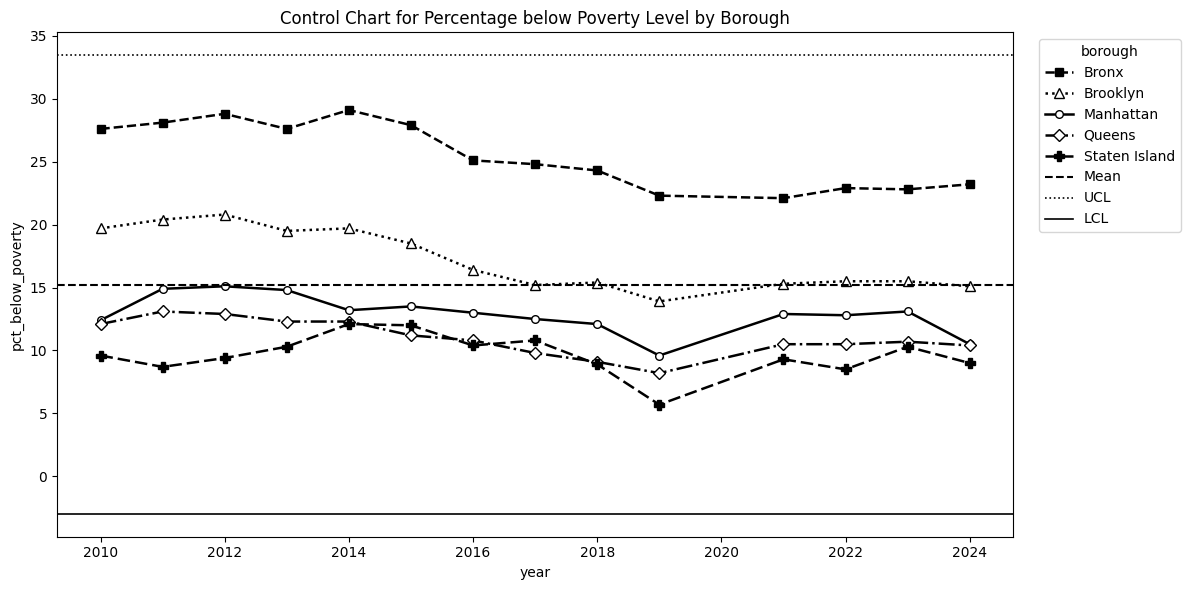

In [2]:
path = "data_csv/ACS_socioeconomic_indicators_2010-2024_Data"

if os.path.isdir(path):
    csv_files = sorted(glob.glob(os.path.join(path, "*.csv")))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {path}")
    csv_path = csv_files[0]
else:
    csv_path = path if os.path.exists(path) else f"{path}.csv"

df = pd.read_csv(csv_path)

borough_col = next((c for c in df.columns if c.lower() in {"borough", "boro", "borough_name"}), None)
if borough_col is None:
    object_cols = df.select_dtypes(include="object").columns.tolist()
    if not object_cols:
        raise ValueError("No borough column found.")
    borough_col = object_cols[0]

value_col = next((c for c in df.columns if c.lower() == "pct_below_poverty"), None)
if value_col is None:
    candidates = [c for c in df.columns if "poverty" in c.lower()]
    if not candidates:
        raise ValueError("No pct_below_poverty column found.")
    value_col = candidates[0]

time_col = next((c for c in df.columns if c.lower() in {"year", "date", "month", "period", "time"}), None)


def prepare_join_frame(frame, year_col, borough_col, value_cols=None, rename_map=None):
    selected_cols = [year_col, borough_col]
    if value_cols:
        selected_cols.extend(value_cols)
    prepared = frame[selected_cols].copy()
    prepared[borough_col] = prepared[borough_col].astype(str).str.strip().str.lower()
    columns_to_rename = {year_col: "year", borough_col: "borough"}
    if rename_map:
        columns_to_rename.update(rename_map)
    return prepared.rename(columns=columns_to_rename)

plt.figure(figsize=(12, 6))

for borough, grp in df.groupby(borough_col, dropna=False):
    grp = grp.copy()
    if time_col is not None:
        grp = grp.sort_values(time_col)
        x = grp[time_col]
    else:
        x = range(len(grp))
    style_key = str(borough).strip().lower()
    borough_style = BOROUGH_MARKER_STYLES.get(style_key, {"marker": "o", "markersize": 5.5, "linestyle": "-", "facecolor": "white"})
    plt.plot(
        x,
        grp[value_col],
        color="black",
        marker=borough_style["marker"],
        markersize=borough_style["markersize"],
        linestyle=borough_style["linestyle"],
        linewidth=1.8,
        markerfacecolor=borough_style["facecolor"],
        markeredgecolor="black",
        label=str(borough),
    )

overall_mean = df[value_col].mean()
overall_std = df[value_col].std(ddof=1)
ucl = overall_mean + 3 * overall_std
lcl = overall_mean - 3 * overall_std

plt.axhline(overall_mean, color="black", linestyle="--", linewidth=1.5, label="Mean")
plt.axhline(ucl, color="black", linestyle=":", linewidth=1.2, label="UCL")
plt.axhline(lcl, color="black", linestyle="-", linewidth=1.2, label="LCL")

plt.title("Control Chart for Percentage below Poverty Level by Borough")
plt.xlabel(time_col if time_col is not None else "Observation")
plt.ylabel("pct_below_poverty")
plt.legend(title=borough_col, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [3]:
asthma_path = "data_csv/merged_asthma_data.csv"
asthma_df = pd.read_csv(asthma_path)

asthma_year_col = next((c for c in asthma_df.columns if c.lower() in {"year", "date", "time", "period"}), None)
asthma_borough_col = next((c for c in asthma_df.columns if c.lower() in {"borough", "boro", "borough_name"}), None)
asthma_rate_col = next((c for c in asthma_df.columns if "asthma_incidence_rate" in c.lower()), None)

if asthma_year_col is None or asthma_borough_col is None or asthma_rate_col is None:
    raise ValueError("Could not find year, borough, or asthma_incidence_rate columns in merged_asthma_data.csv")

acs_subset = prepare_join_frame(df, time_col, borough_col, ["median_hh_income"])
asthma_subset = prepare_join_frame(
    asthma_df,
    asthma_year_col,
    asthma_borough_col,
    [asthma_rate_col],
    {asthma_rate_col: "asthma_incidence_rate"}
)

merged_corr = pd.merge(
    asthma_subset,
    acs_subset,
    on=["year", "borough"],
    how="inner"
).dropna(subset=["asthma_incidence_rate", "median_hh_income"])

corr_value = merged_corr["asthma_incidence_rate"].corr(merged_corr["median_hh_income"])

print(f"Pearson correlation between asthma_incidence_rate and median_hh_income: {corr_value:.4f}")
display(merged_corr.head())

Pearson correlation between asthma_incidence_rate and median_hh_income: -0.8201


,year,borough,asthma_incidence_rate,median_hh_income
0,2010,bronx,670.317173,32568
1,2010,brooklyn,307.653667,42143
2,2010,manhattan,237.537326,63832
3,2010,queens,208.609297,53054
4,2010,staten island,198.566994,70560


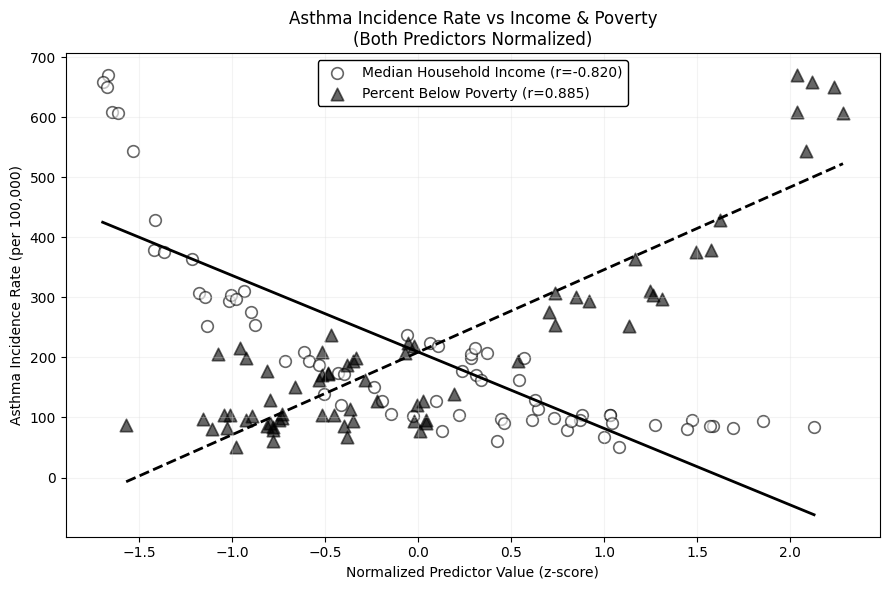

,year,borough,asthma_incidence_rate,median_hh_income,pct_below_poverty
0,2010,bronx,670.317173,32568,27.6
1,2010,brooklyn,307.653667,42143,19.7
2,2010,manhattan,237.537326,63832,12.4
3,2010,queens,208.609297,53054,12.1
4,2010,staten island,198.566994,70560,9.6


In [4]:
# Build merged_poverty_corr from ACS poverty data and asthma data
acs_poverty_subset = df[[time_col, borough_col, value_col]].copy()
asthma_subset = asthma_df[[asthma_year_col, asthma_borough_col, asthma_rate_col]].copy()

acs_poverty_subset[borough_col] = acs_poverty_subset[borough_col].astype(str).str.strip().str.lower()
asthma_subset[asthma_borough_col] = asthma_subset[asthma_borough_col].astype(str).str.strip().str.lower()

merged_poverty_corr = pd.merge(
    asthma_subset.rename(columns={asthma_year_col: "year", asthma_borough_col: "borough", asthma_rate_col: "asthma_incidence_rate"}),
    acs_poverty_subset.rename(columns={time_col: "year", borough_col: "borough"}),
    on=["year", "borough"],
    how="inner"
).dropna(subset=["asthma_incidence_rate", value_col])

# Merge both predictors (income + poverty) into a single frame for consistent comparison
merged_both = pd.merge(
    merged_corr,
    merged_poverty_corr[["year", "borough", value_col]],
    on=["year", "borough"],
    how="inner"
).dropna(subset=["asthma_incidence_rate", "median_hh_income", value_col])

# Compute Pearson correlations on the merged frame
corr_income = merged_both["asthma_incidence_rate"].corr(merged_both["median_hh_income"])
corr_poverty = merged_both["asthma_incidence_rate"].corr(merged_both[value_col])

# Normalize predictors (z-scores) using the merged frame
income_norm = (merged_both["median_hh_income"] - merged_both["median_hh_income"].mean()) / merged_both["median_hh_income"].std()
poverty_norm = (merged_both[value_col] - merged_both[value_col].mean()) / merged_both[value_col].std()

fig, ax = plt.subplots(figsize=(9, 6))

# Scatter: Income — open circles
ax.scatter(income_norm, merged_both["asthma_incidence_rate"],
           alpha=0.6, s=70, marker="o", facecolors="white", edgecolors="black",
           linewidths=1.2, label=f"Median Household Income (r={corr_income:.3f})")

# Regression line: Income — solid
z1 = np.polyfit(income_norm, merged_both["asthma_incidence_rate"], 1)
p1 = np.poly1d(z1)
x1_line = np.linspace(income_norm.min(), income_norm.max(), 200)
ax.plot(x1_line, p1(x1_line), color="black", linewidth=2, linestyle="-")

# Scatter: Poverty — filled triangles
ax.scatter(poverty_norm, merged_both["asthma_incidence_rate"],
           alpha=0.6, s=80, marker="^", facecolors="black", edgecolors="black",
           linewidths=1.2, label=f"Percent Below Poverty (r={corr_poverty:.3f})")

# Regression line: Poverty — dashed
z2 = np.polyfit(poverty_norm, merged_both["asthma_incidence_rate"], 1)
p2 = np.poly1d(z2)
x2_line = np.linspace(poverty_norm.min(), poverty_norm.max(), 200)
ax.plot(x2_line, p2(x2_line), color="black", linewidth=2, linestyle="--")

ax.set_xlabel("Normalized Predictor Value (z-score)")
ax.set_ylabel("Asthma Incidence Rate (per 100,000)")
ax.set_title("Asthma Incidence Rate vs Income & Poverty\n(Both Predictors Normalized)")
ax.legend(loc="upper center", framealpha=1, edgecolor="black")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quick preview of the merged frame used for plotting
display(merged_both.head())